<a href="https://colab.research.google.com/github/carolshayle/Python/blob/main/Microsoft%20Planetary%20Catalog%20for%20Mogadishu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 2. Setup Microsoft Planetary Computer Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Years to analyze (2024 acts as our "Current/Latest" for 2026 projection)
years = [1990, 2000, 2010, 2020, 2024]
urban_results = {}

print("Fetching data from cloud...")

for year in years:
    try:
        # Search Landsat Collection 2 Level 2
        search = catalog.search(
            collections=["landsat-c2-l2"],
            bbox=bbox,
            datetime=f"{year}-01-01/{year}-12-31",
            query={"eo:cloud_cover": {"lt": 15}},
        )

        items = search.item_collection()
        if len(items) == 0:
            print(f"No images found for {year}")
            continue

        # Stream the pixels (only within the bbox)
        # Landsat 4-7 use different band names than Landsat 8-9
        asset_names = ["swir16", "nir08"] # Planetary Computer standardized names

        data = stackstac.stack(
            items,
            bounds_latlon=bbox,
            epsg=32638, # UTM Zone for Mogadishu
            assets=asset_names,
        ).median(dim="time")

        # Calculate NDBI: (SWIR - NIR) / (SWIR + NIR)
        # This highlights urban/built-up structures
        swir = data.sel(band="swir16")
        nir = data.sel(band="nir08")
        ndbi = (swir - nir) / (swir + nir)

        # Threshold: 0.05 is standard for urban areas in dry climates
        urban_mask = ndbi > 0.05
        urban_results[year] = urban_mask
        print(f"Year {year} processed.")

    except Exception as e:
        print(f"Error processing {year}: {e}")

Fetching data from cloud...
Year 1990 processed.
Year 2000 processed.
Year 2010 processed.
Year 2020 processed.
Year 2024 processed.


In [ ]:
# 2. Setup Microsoft Planetary Computer Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Years to analyze (2024 acts as our "Current/Latest" for 2026 projection)
years = [1990, 2000, 2010, 2020, 2024]
urban_results = {}

print("Fetching data from cloud...")

for year in years:
    try:
        # Search Landsat Collection 2 Level 2
        search = catalog.search(
            collections=["landsat-c2-l2"],
            bbox=bbox,
            datetime=f"{year}-01-01/{year}-12-31",
            query={"eo:cloud_cover": {"lt": 15}},
        )

        items = search.item_collection()
        if len(items) == 0:
            print(f"No images found for {year}")
            continue

        # Stream the pixels (only within the bbox)
        # Landsat 4-7 use different band names than Landsat 8-9
        asset_names = ["swir16", "nir08"] # Planetary Computer standardized names

        data = stackstac.stack(
            items,
            bounds_latlon=bbox,
            epsg=32638, # UTM Zone for Mogadishu
            assets=asset_names,
        ).median(dim="time")

        # Calculate NDBI: (SWIR - NIR) / (SWIR + NIR)
        # This highlights urban/built-up structures
        swir = data.sel(band="swir16")
        nir = data.sel(band="nir08")
        ndbi = (swir - nir) / (swir + nir)

        # Threshold: 0.05 is standard for urban areas in dry climates
        urban_mask = ndbi > 0.05
        urban_results[year] = urban_mask
        print(f"Year {year} processed.")

    except Exception as e:
        print(f"Error processing {year}: {e}")

Fetching data from cloud...
Year 1990 processed.
Year 2000 processed.
Year 2010 processed.
Year 2020 processed.
Year 2024 processed.


In [1]:
!pip install pystac-client planetary-computer stackstac geopandas rasterio matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 7.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
import os

print("Upload all shapefile components (.shp, .shx, .dbf, .prj):")
uploaded = files.upload()

# Identify the .shp file name
shp_file = [f for f in uploaded.keys() if f.endswith('.shp')][0]
print(f"Using shapefile: {shp_file}")

Upload all shapefile components (.shp, .shx, .dbf, .prj):


Saving Banaadir_Region.cpg to Banaadir_Region.cpg
Saving Banaadir_Region.dbf to Banaadir_Region.dbf
Saving Banaadir_Region.prj to Banaadir_Region.prj
Saving Banaadir_Region.sbn to Banaadir_Region.sbn
Saving Banaadir_Region.sbx to Banaadir_Region.sbx
Saving Banaadir_Region.shp to Banaadir_Region.shp
Saving Banaadir_Region.shp.xml to Banaadir_Region.shp.xml
Saving Banaadir_Region.shx to Banaadir_Region.shx
Using shapefile: Banaadir_Region.shp


In [3]:
import pystac_client
import planetary_computer
import stackstac
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [4]:
# 1. Load the Shapefile
mogadishu_gdf = gpd.read_file(shp_file)
if mogadishu_gdf.crs != "EPSG:4326":
    mogadishu_gdf = mogadishu_gdf.to_crs("EPSG:4326")

# Get bounding box for the search
bbox = mogadishu_gdf.total_bounds


In [5]:
# 2. Setup Microsoft Planetary Computer Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Years to analyze (2024 acts as our "Current/Latest" for 2026 projection)
years = [1990, 2000, 2010, 2020, 2024]
urban_results = {}

print("Fetching data from cloud...")

for year in years:
    try:
        # Search Landsat Collection 2 Level 2
        search = catalog.search(
            collections=["landsat-c2-l2"],
            bbox=bbox,
            datetime=f"{year}-01-01/{year}-12-31",
            query={"eo:cloud_cover": {"lt": 15}},
        )

        items = search.item_collection()
        if len(items) == 0:
            print(f"No images found for {year}")
            continue

        # Stream the pixels (only within the bbox)
        # Landsat 4-7 use different band names than Landsat 8-9
        asset_names = ["swir16", "nir08"] # Planetary Computer standardized names

        data = stackstac.stack(
            items,
            bounds_latlon=bbox,
            epsg=32638, # UTM Zone for Mogadishu
            assets=asset_names,
        ).median(dim="time")

        # Calculate NDBI: (SWIR - NIR) / (SWIR + NIR)
        # This highlights urban/built-up structures
        swir = data.sel(band="swir16")
        nir = data.sel(band="nir08")
        ndbi = (swir - nir) / (swir + nir)

        # Threshold: 0.05 is standard for urban areas in dry climates
        urban_mask = ndbi > 0.05
        urban_results[year] = urban_mask
        print(f"Year {year} processed.")

    except Exception as e:
        print(f"Error processing {year}: {e}")

Fetching data from cloud...
Year 1990 processed.
Year 2000 processed.
Year 2010 processed.
Year 2020 processed.
Year 2024 processed.


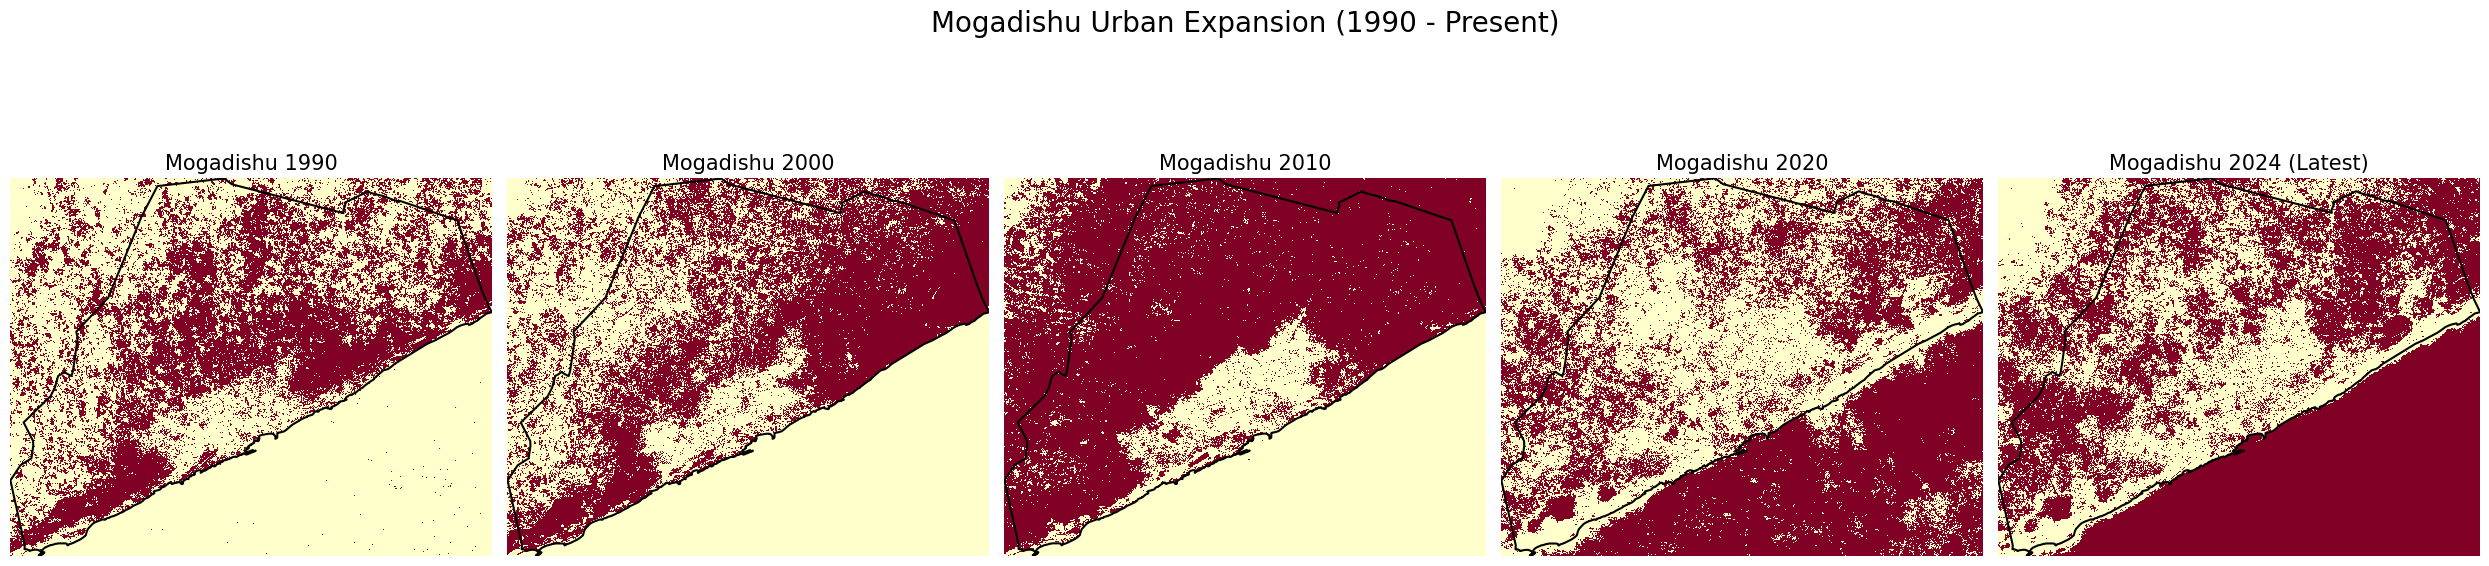

In [6]:
# 3. Visualization
num_plots = len(urban_results)
fig, axes = plt.subplots(1, num_plots, figsize=(25, 7), facecolor='white')

for i, (year, mask) in enumerate(urban_results.items()):
    # Plot the Urban Extent
    mask.plot(ax=axes[i], cmap="YlOrRd", add_colorbar=False)

    # Overlay the Shapefile Boundary
    mogadishu_gdf.to_crs(epsg=32638).plot(ax=axes[i], edgecolor='black', facecolor='none', linewidth=1.5)

    title = f"Mogadishu {year}" if year < 2024 else "Mogadishu 2024 (Latest)"
    axes[i].set_title(title, fontsize=15)
    axes[i].set_axis_off()

plt.suptitle("Mogadishu Urban Expansion (1990 - Present)", fontsize=20)
plt.tight_layout()
plt.show()

In [7]:
# 4. Area Calculation
print("\n--- Estimated Urban Footprint ---")
for year, mask in urban_results.items():
    # Count pixels where True (Urban), each pixel is 30m x 30m
    area_km2 = (mask.sum().values * 900) / 1_000_000
    print(f"Year {year}: {area_km2:.2f} km²")


--- Estimated Urban Footprint ---


Year 1990: 319.46 km²


Year 2000: 382.89 km²


Year 2010: 555.65 km²


Year 2020: 507.75 km²


Year 2024: 602.04 km²


In [8]:
# Simple Linear Projection for 2026
area_2010 = (urban_results[2010].sum().values * 900) / 1_000_000
area_2020 = (urban_results[2020].sum().values * 900) / 1_000_000

# Annual Growth Rate
annual_growth = (area_2020 - area_2010) / 10

# Projected 2026
area_2026 = area_2020 + (annual_growth * 6)

print(f"Projected Urban Extent for 2026: {area_2026:.2f} km²")

Projected Urban Extent for 2026: 479.01 km²
